In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
rows = [
    ["Pearson", "LinearModel", 0.78],
    ["Pearson", "RandomForest", 0.84],
    ["PartialCorr", "LinearModel", 0.72],
    ["PartialCorr", "RandomForest", 0.80],
    ["MutualInfo", "LinearModel", 0.69],
    ["MutualInfo", "RandomForest", 0.77]
]

df = pd.DataFrame(
    rows,
    columns=["estimator", "model", "performance_score"]
)

df

,estimator,model,performance_score
0,Pearson,LinearModel,0.78
1,Pearson,RandomForest,0.84
2,PartialCorr,LinearModel,0.72
3,PartialCorr,RandomForest,0.80
4,MutualInfo,LinearModel,0.69
5,MutualInfo,RandomForest,0.77


In [4]:
pivot = df.pivot(
    index="estimator",
    columns="model",
    values="performance_score"
)

pivot

model,LinearModel,RandomForest
estimator,,
MutualInfo,0.69,0.77
PartialCorr,0.72,0.80
Pearson,0.78,0.84


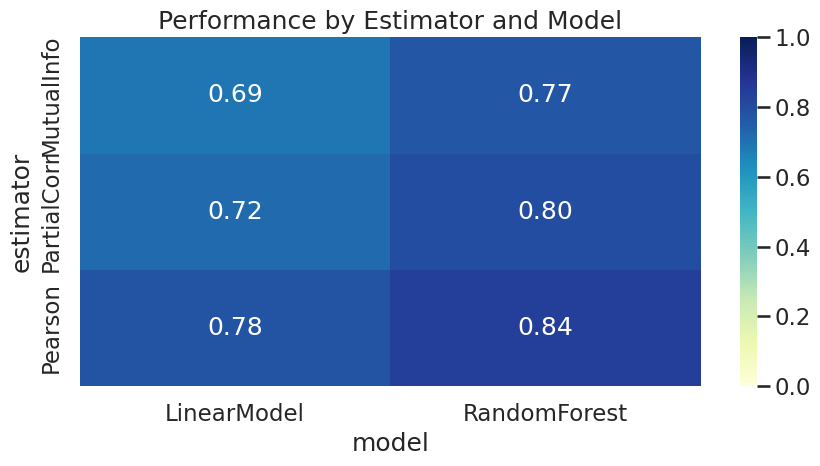

In [5]:
plt.figure(figsize=(9,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title("Performance by Estimator and Model")
plt.tight_layout()
plt.savefig("figures/03_model_choice_heatmap.png", dpi=300)
plt.show()

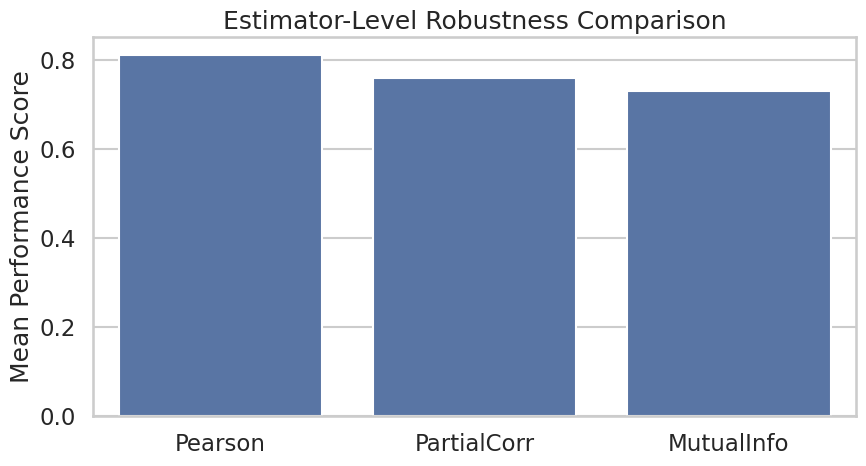

In [6]:
summary = (
    df.groupby("estimator")["performance_score"]
    .mean()
    .reset_index()
    .sort_values("performance_score", ascending=False)
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=summary,
    x="estimator",
    y="performance_score"
)

plt.xlabel("")
plt.ylabel("Mean Performance Score")
plt.title("Estimator-Level Robustness Comparison")
plt.tight_layout()
plt.savefig("figures/03_estimator_summary.png", dpi=300)
plt.show()

In [7]:
df.to_csv("outputs/03_model_choice_scores.csv", index=False)
summary.to_csv("outputs/03_estimator_summary.csv", index=False)

summary

,estimator,performance_score
2,Pearson,0.81
1,PartialCorr,0.76
0,MutualInfo,0.73
